<a href="https://colab.research.google.com/github/krishshah8000/mlproject/blob/master/IPL_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Shaowing Data

In [ ]:
df = pd.read_csv('matches.csv')
df.head(10)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan
5,335987,2007/08,Jaipur,2008-04-21,League,SR Watson,Sawai Mansingh Stadium,Rajasthan Royals,Kings XI Punjab,Kings XI Punjab,bat,Rajasthan Royals,wickets,6.0,167.0,20.0,N,NaN,Aleem Dar,RB Tiffin
6,335988,2007/08,Hyderabad,2008-04-22,League,V Sehwag,"Rajiv Gandhi International Stadium, Uppal",Deccan Chargers,Delhi Daredevils,Deccan Chargers,bat,Delhi Daredevils,wickets,9.0,143.0,20.0,N,NaN,IL Howell,AM Saheba
7,335989,2007/08,Chennai,2008-04-23,League,ML Hayden,"MA Chidambaram Stadium, Chepauk",Chennai Super Kings,Mumbai Indians,Mumbai Indians,field,Chennai Super Kings,runs,6.0,209.0,20.0,N,NaN,DJ Harper,GA Pratapkumar
8,335990,2007/08,Hyderabad,2008-04-24,League,YK Pathan,"Rajiv Gandhi International Stadium, Uppal",Deccan Chargers,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,3.0,215.0,20.0,N,NaN,Asad Rauf,MR Benson
9,335991,2007/08,Chandigarh,2008-04-25,League,KC Sangakkara,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Mumbai Indians,Mumbai Indians,field,Kings XI Punjab,runs,66.0,183.0,20.0,N,NaN,Aleem Dar,AM Saheba


Data Cleaning Process

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [ ]:
df_modified = df.drop(['method', 'umpire1', 'umpire2'], axis=1)

df_modified.to_csv('matches_modified.csv', index=False)
df = pd.read_csv('matches_modified.csv')

df['team1'] = df['team1'].replace(['Royal Challengers Bengaluru'], 'Royal Challengers Bangalore')
df['team2'] = df['team2'].replace(['Royal Challengers Bengaluru'], 'Royal Challengers Bangalore')
df['winner'] = df['winner'].replace(['Royal Challengers Bengaluru'], 'Royal Challengers Bangalore')

df['team1'] = df['team1'].replace(['Kings XI Punjab'], 'Punjab Kings')
df['team2'] = df['team2'].replace(['Kings XI Punjab'], 'Punjab Kings')
df['winner'] = df['winner'].replace(['Kings XI Punjab'], 'Punjab Kings')

df['team1'] = df['team1'].replace(['Delhi Daredevils'], 'Delhi Capitals')
df['team2'] = df['team2'].replace(['Delhi Daredevils'], 'Delhi Capitals')
df['winner'] = df['winner'].replace(['Delhi Daredevils'], 'Delhi Capitals')

df['team1'] = df['team1'].replace(['Rising Pune Supergiant'], 'Rising Pune Supergiants')
df['team2'] = df['team2'].replace(['Rising Pune Supergiant'], 'Rising Pune Supergiants')
df['winner'] = df['winner'].replace(['Rising Pune Supergiant'], 'Rising Pune Supergiants')



In [ ]:
df.to_csv('matches_cleaned.csv', index=False)
df = pd.read_csv('matches_cleaned.csv')
df.head(10)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,wickets,9.0,130.0,20.0,N
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N
5,335987,2007/08,Jaipur,2008-04-21,League,SR Watson,Sawai Mansingh Stadium,Rajasthan Royals,Punjab Kings,Kings XI Punjab,bat,Rajasthan Royals,wickets,6.0,167.0,20.0,N
6,335988,2007/08,Hyderabad,2008-04-22,League,V Sehwag,"Rajiv Gandhi International Stadium, Uppal",Deccan Chargers,Delhi Capitals,Deccan Chargers,bat,Delhi Capitals,wickets,9.0,143.0,20.0,N
7,335989,2007/08,Chennai,2008-04-23,League,ML Hayden,"MA Chidambaram Stadium, Chepauk",Chennai Super Kings,Mumbai Indians,Mumbai Indians,field,Chennai Super Kings,runs,6.0,209.0,20.0,N
8,335990,2007/08,Hyderabad,2008-04-24,League,YK Pathan,"Rajiv Gandhi International Stadium, Uppal",Deccan Chargers,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,3.0,215.0,20.0,N
9,335991,2007/08,Chandigarh,2008-04-25,League,KC Sangakkara,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Mumbai Indians,Mumbai Indians,field,Punjab Kings,runs,66.0,183.0,20.0,N


### **EDA Process Start**

Total matches played each season

In [ ]:
matches_per_season = df['season'].value_counts().sort_index()
print("Total matches played each season:")
display(matches_per_season)

Total matches played each season:


,count
season,
2007/08,58
2009,57
2009/10,60
2011,73
2012,74
2013,76
2014,60
2015,59
2016,60


/tmp/ipython-input-2612241808.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=matches_per_season.index, y=matches_per_season.values, palette='viridis')


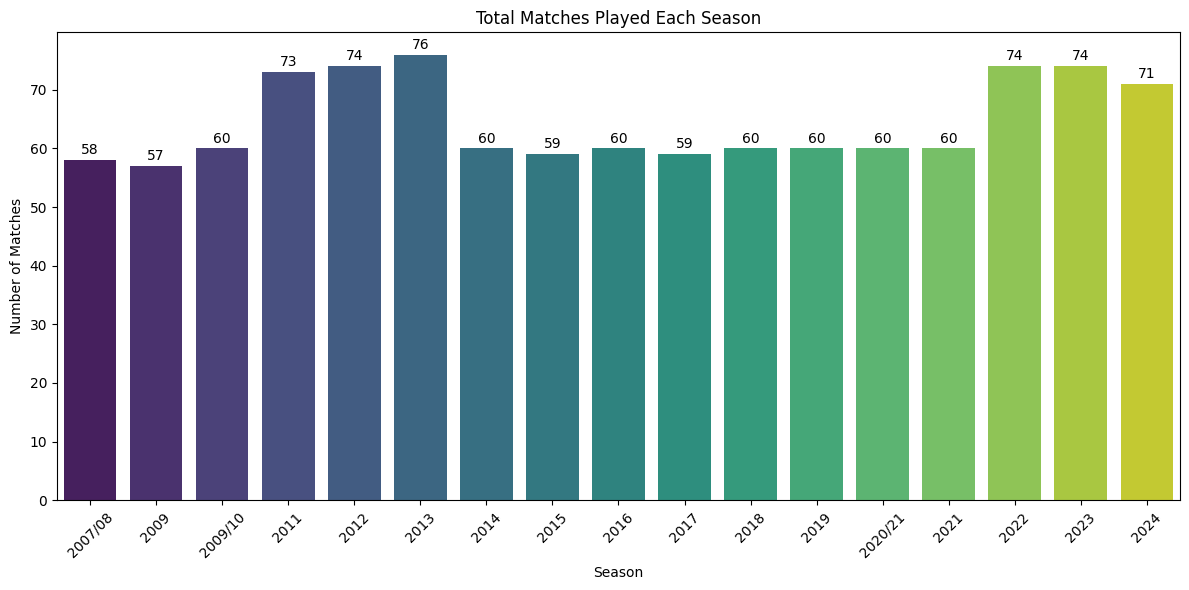

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x=matches_per_season.index, y=matches_per_season.values, palette='viridis')
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.title("Total Matches Played Each Season")
plt.xticks(rotation=45)
for i, count in enumerate(matches_per_season.values):
    plt.text(i, count + 1, str(count), ha='center')
plt.tight_layout()
plt.show()

Average number of matches played per season

In [ ]:
average_matches = matches_per_season.mean()
print(f"The average number of matches played per season is: {average_matches:.2f}")

The average number of matches played per season is: 64.41


Total Matches Played by Each Team

In [ ]:
team_matches = pd.concat([df['team1'], df['team2']]).value_counts()
print("Total matches played by each team:")
display(team_matches)

Total matches played by each team:


,count
Mumbai Indians,261
Royal Challengers Bangalore,255
Delhi Capitals,252
Kolkata Knight Riders,251
Punjab Kings,246
Chennai Super Kings,238
Rajasthan Royals,221
Sunrisers Hyderabad,182
Deccan Chargers,75
Pune Warriors,46


/tmp/ipython-input-1583025860.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=team_matches.index, y=team_matches.values, palette='viridis')


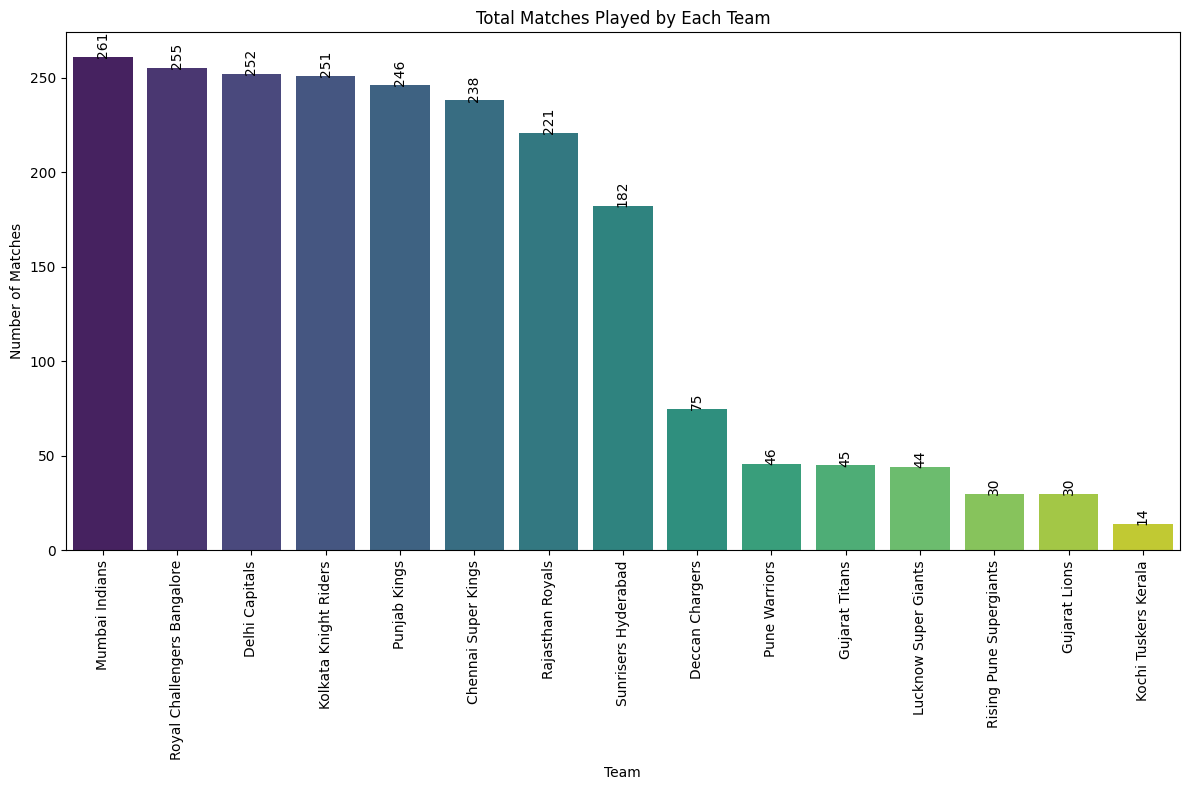

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(x=team_matches.index, y=team_matches.values, palette='viridis')
plt.xlabel("Team")
plt.ylabel("Number of Matches")
plt.title("Total Matches Played by Each Team")
plt.xticks(rotation=90)
for i, count in enumerate(team_matches.values):
    plt.text(i, count + 1, str(count), ha='center', rotation=90)
plt.tight_layout()
plt.show()

Shaowing Each team wins and losses




In [ ]:
wins = df['winner'].value_counts()
losses = team_matches - wins

In [ ]:
win_loss_df = pd.DataFrame({'Wins': wins, 'Losses': losses})
display(win_loss_df)

,Wins,Losses
Chennai Super Kings,138,100
Deccan Chargers,29,46
Delhi Capitals,115,137
Gujarat Lions,13,17
Gujarat Titans,28,17
Kochi Tuskers Kerala,6,8
Kolkata Knight Riders,131,120
Lucknow Super Giants,24,20
Mumbai Indians,144,117
Pune Warriors,12,34


Showing Each Team wins and losses using paired bar chart

In [ ]:
win_loss_df = win_loss_df.reset_index()
win_loss_melted = win_loss_df.melt(id_vars='index', var_name='Type', value_name='Count')
win_loss_melted = win_loss_melted.rename(columns={'index': 'Team'})


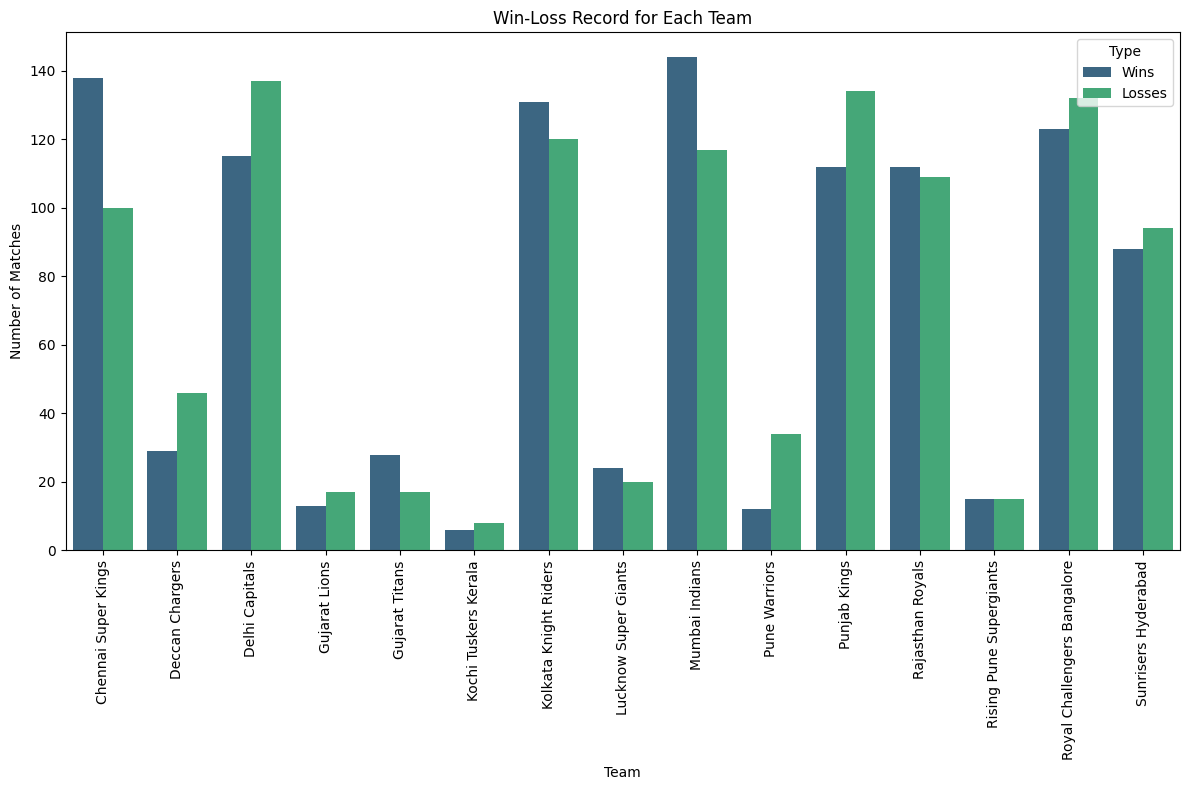

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Team', y='Count', hue='Type', data=win_loss_melted, palette='viridis')
plt.xlabel("Team")
plt.ylabel("Number of Matches")
plt.title("Win-Loss Record for Each Team")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Showing each team winning percentage throught the IPL

In [ ]:
win_loss_df['Win Percentage'] = (win_loss_df['Wins'] / (win_loss_df['Wins'] + win_loss_df['Losses'])) * 100
win_loss_df_sorted = win_loss_df.sort_values(by='Win Percentage', ascending=False)
display(win_loss_df_sorted)

,index,Wins,Losses,Win Percentage
4,Gujarat Titans,28,17,62.222222
0,Chennai Super Kings,138,100,57.983193
8,Mumbai Indians,144,117,55.172414
7,Lucknow Super Giants,24,20,54.545455
6,Kolkata Knight Riders,131,120,52.191235
11,Rajasthan Royals,112,109,50.678733
12,Rising Pune Supergiants,15,15,50.000000
14,Sunrisers Hyderabad,88,94,48.351648
13,Royal Challengers Bangalore,123,132,48.235294
2,Delhi Capitals,115,137,45.634921


Shows that which player has highest player of the match award



In [ ]:
player_of_match_counts = df['player_of_match'].value_counts()
sorted_player_awards = player_of_match_counts.sort_values(ascending=False)
display(sorted_player_awards)

,count
player_of_match,
AB de Villiers,25
CH Gayle,22
RG Sharma,19
DA Warner,18
V Kohli,18
...,...
DR Sams,1
KS Bharat,1
Shashank Singh,1


Select top 10 players from the list



In [ ]:
top_10_players = sorted_player_awards.head(10)
print("Top 10 Players with Most Player of the Match Awards:")
display(top_10_players)

Top 10 Players with Most Player of the Match Awards:


,count
player_of_match,
AB de Villiers,25
CH Gayle,22
RG Sharma,19
DA Warner,18
V Kohli,18
MS Dhoni,17
RA Jadeja,16
SR Watson,16
YK Pathan,16


Player of match year by year

In [ ]:
df['year'] = pd.to_datetime(df['date']).dt.year

player_of_match_by_year = df.groupby(['year', 'player_of_match']).size().reset_index(name='award_count')

player_of_match_by_year_sorted = player_of_match_by_year.sort_values(by=['year', 'award_count'], ascending=[True, False])
display(player_of_match_by_year_sorted)

,year,player_of_match,award_count
28,2008,SE Marsh,5
33,2008,SR Watson,4
39,2008,YK Pathan,4
3,2008,AC Gilchrist,2
17,2008,M Ntini,2
...,...,...,...
753,2024,Simarjeet Singh,1
754,2024,TA Boult,1
757,2024,VR Iyer,1
758,2024,WG Jacks,1


Show top 20 players who have highest player of the match award in a year


In [ ]:
player_who_won_player_of_match_award = player_of_match_by_year_sorted.sort_values(by='award_count', ascending=False)
top_20_players = player_who_won_player_of_match_award.head(20)
print("Top 20 Players with Most Player of the Match Awards in a year:")
display(top_20_players)

Top 20 Players with Most Player of the Match Awards in a year:


,year,player_of_match,award_count
133,2011,CH Gayle,6
28,2008,SE Marsh,5
253,2013,MEK Hussey,5
386,2016,V Kohli,5
188,2012,CH Gayle,5
592,2021,RD Gaikwad,4
475,2019,AD Russell,4
356,2016,AB de Villiers,4
121,2010,SR Tendulkar,4
707,2023,YBK Jaiswal,4


Show the player with the highest 'Player of the Match' awards in each year and also Shows in sorted order

In [ ]:
top_player_each_year = player_of_match_by_year_sorted.groupby('year').head(1)
display(top_player_each_year)

,year,player_of_match,award_count
28,2008,SE Marsh,5
80,2009,YK Pathan,3
121,2010,SR Tendulkar,4
133,2011,CH Gayle,6
188,2012,CH Gayle,5
253,2013,MEK Hussey,5
285,2014,GJ Maxwell,4
319,2015,DA Warner,4
386,2016,V Kohli,5
392,2017,BA Stokes,3


In [ ]:
top_player_each_year = top_player_each_year.sort_values(by='award_count', ascending=False)
display(top_player_each_year)

,year,player_of_match,award_count
133,2011,CH Gayle,6
28,2008,SE Marsh,5
188,2012,CH Gayle,5
386,2016,V Kohli,5
253,2013,MEK Hussey,5
285,2014,GJ Maxwell,4
121,2010,SR Tendulkar,4
319,2015,DA Warner,4
462,2018,Rashid Khan,4
702,2023,Shubman Gill,4


Shows Stadiums list with its city

In [ ]:
stadium_city = df[['venue', 'city']].drop_duplicates()
display(stadium_city)

,venue,city
0,M Chinnaswamy Stadium,Bangalore
1,"Punjab Cricket Association Stadium, Mohali",Chandigarh
2,Feroz Shah Kotla,Delhi
3,Wankhede Stadium,Mumbai
4,Eden Gardens,Kolkata
...,...,...
957,"Barsapara Cricket Stadium, Guwahati",Guwahati
975,"Sawai Mansingh Stadium, Jaipur",Jaipur
1013,"Himachal Pradesh Cricket Association Stadium, ...",Dharamsala
1025,Maharaja Yadavindra Singh International Cricke...,Mohali


Show Stadiums per city

In [ ]:
stadiums_per_city = stadium_city['city'].value_counts()
display(stadiums_per_city)

,count
city,
Mumbai,6
Chandigarh,4
Delhi,3
Chennai,3
Pune,3
Hyderabad,3
Bengaluru,2
Jaipur,2
Ahmedabad,2


/tmp/ipython-input-2814175768.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stadiums_per_city.index, y=stadiums_per_city.values, palette='viridis')


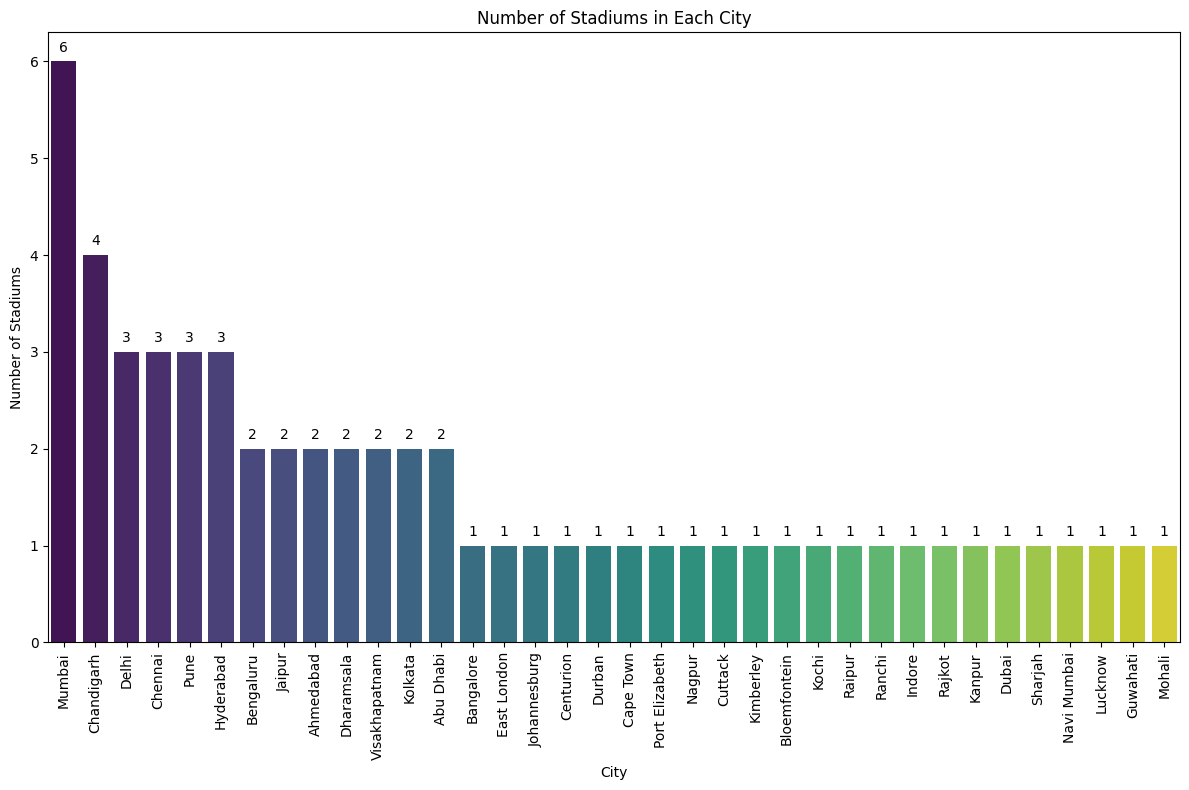

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(x=stadiums_per_city.index, y=stadiums_per_city.values, palette='viridis')
plt.xlabel("City")
plt.ylabel("Number of Stadiums")
plt.title("Number of Stadiums in Each City")
plt.xticks(rotation=90)
for i, count in enumerate(stadiums_per_city.values):
    plt.text(i, count + 0.1, str(count), ha='center')
plt.tight_layout()
plt.show()

Each team played matches at each stadium

In [ ]:
team1_counts = df.groupby(['venue', 'team1']).size().reset_index(name='total_matches')
team1_counts = team1_counts.rename(columns={'team1': 'team'})
team2_counts = df.groupby(['venue', 'team2']).size().reset_index(name='total_matches')
team2_counts = team2_counts.rename(columns={'team2': 'team'})

In [ ]:
total_matches_per_stadium_per_team = pd.concat([team1_counts, team2_counts]).groupby(['venue', 'team']).sum().reset_index()
display(total_matches_per_stadium_per_team)

,venue,team,total_matches
0,Arun Jaitley Stadium,Chennai Super Kings,2
1,Arun Jaitley Stadium,Delhi Capitals,14
2,Arun Jaitley Stadium,Kolkata Knight Riders,2
3,Arun Jaitley Stadium,Mumbai Indians,2
4,Arun Jaitley Stadium,Punjab Kings,2
...,...,...,...
474,"Zayed Cricket Stadium, Abu Dhabi",Mumbai Indians,3
475,"Zayed Cricket Stadium, Abu Dhabi",Punjab Kings,1
476,"Zayed Cricket Stadium, Abu Dhabi",Rajasthan Royals,2
477,"Zayed Cricket Stadium, Abu Dhabi",Royal Challengers Bangalore,2


In [ ]:
pivot_table_matches = total_matches_per_stadium_per_team.pivot(index='team', columns='venue', values='total_matches').fillna(0)
display(pivot_table_matches)

venue,Arun Jaitley Stadium,"Arun Jaitley Stadium, Delhi",Barabati Stadium,"Barsapara Cricket Stadium, Guwahati","Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow",Brabourne Stadium,"Brabourne Stadium, Mumbai",Buffalo Park,De Beers Diamond Oval,Dr DY Patil Sports Academy,...,Shaheed Veer Narayan Singh International Stadium,Sharjah Cricket Stadium,Sheikh Zayed Stadium,St George's Park,Subrata Roy Sahara Stadium,SuperSport Park,"Vidarbha Cricket Association Stadium, Jamtha",Wankhede Stadium,"Wankhede Stadium, Mumbai","Zayed Cricket Stadium, Abu Dhabi"
team,,,,,,,,,,,,,,,,,,,,,
Chennai Super Kings,2.0,3.0,1.0,0.0,2.0,1.0,4.0,1.0,1.0,4.0,...,1.0,6.0,6.0,2.0,2.0,3.0,1.0,14.0,11.0,2.0
Deccan Chargers,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,2.0,6.0,...,0.0,0.0,0.0,1.0,1.0,4.0,3.0,2.0,0.0,0.0
Delhi Capitals,14.0,12.0,1.0,1.0,2.0,2.0,4.0,1.0,0.0,2.0,...,6.0,8.0,6.0,1.0,3.0,4.0,0.0,9.0,9.0,1.0
Gujarat Lions,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
Gujarat Titans,0.0,2.0,0.0,0.0,2.0,0.0,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0
Kochi Tuskers Kerala,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
Kolkata Knight Riders,2.0,1.0,3.0,0.0,1.0,2.0,3.0,1.0,0.0,2.0,...,1.0,8.0,11.0,2.0,3.0,2.0,0.0,9.0,8.0,3.0
Lucknow Super Giants,0.0,1.0,0.0,0.0,14.0,0.0,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0
Mumbai Indians,2.0,4.0,1.0,0.0,2.0,7.0,4.0,2.0,0.0,7.0,...,0.0,6.0,9.0,3.0,2.0,3.0,0.0,67.0,18.0,3.0


Highest played top 5 stadiums for each team

In [ ]:
top_stadiums_per_team = total_matches_per_stadium_per_team.sort_values(by=['team', 'total_matches'], ascending=[True, False])
top_5_stadiums_per_team = top_stadiums_per_team.groupby('team').head(5).reset_index(drop=True)
display(top_5_stadiums_per_team)

,venue,team,total_matches
0,"MA Chidambaram Stadium, Chepauk",Chennai Super Kings,47
1,"MA Chidambaram Stadium, Chepauk, Chennai",Chennai Super Kings,15
2,Dubai International Cricket Stadium,Chennai Super Kings,14
3,Wankhede Stadium,Chennai Super Kings,14
4,Eden Gardens,Chennai Super Kings,11
...,...,...,...
70,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,30
71,Rajiv Gandhi International Stadium,Sunrisers Hyderabad,14
72,Dubai International Cricket Stadium,Sunrisers Hyderabad,13
73,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Sunrisers Hyderabad,13


List teams with their top 5 played stadiums

In [ ]:
stadiums_by_team = top_5_stadiums_per_team.groupby('team')['venue'].unique()
display(stadiums_by_team)

,venue
team,
Chennai Super Kings,"[MA Chidambaram Stadium, Chepauk, MA Chidambar..."
Deccan Chargers,"[Rajiv Gandhi International Stadium, Uppal, Dr..."
Delhi Capitals,"[Feroz Shah Kotla, Dubai International Cricket..."
Gujarat Lions,"[Saurashtra Cricket Association Stadium, Green..."
Gujarat Titans,"[Narendra Modi Stadium, Ahmedabad, Wankhede St..."
Kochi Tuskers Kerala,"[Nehru Stadium, Holkar Cricket Stadium, Dr DY ..."
Kolkata Knight Riders,"[Eden Gardens, Eden Gardens, Kolkata, M Chinna..."
Lucknow Super Giants,[Bharat Ratna Shri Atal Bihari Vajpayee Ekana ...
Mumbai Indians,"[Wankhede Stadium, Wankhede Stadium, Mumbai, E..."


Team with thier highest played matches

In [ ]:
stadium_highest_matches_played = top_5_stadiums_per_team.groupby('team').head(1).reset_index(drop=True)
display(stadium_highest_matches_played)

,venue,team,total_matches
0,"MA Chidambaram Stadium, Chepauk",Chennai Super Kings,47
1,"Rajiv Gandhi International Stadium, Uppal",Deccan Chargers,18
2,Feroz Shah Kotla,Delhi Capitals,56
3,Saurashtra Cricket Association Stadium,Gujarat Lions,10
4,"Narendra Modi Stadium, Ahmedabad",Gujarat Titans,16
5,Nehru Stadium,Kochi Tuskers Kerala,5
6,Eden Gardens,Kolkata Knight Riders,74
7,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow Super Giants,14
8,Wankhede Stadium,Mumbai Indians,67
9,Subrata Roy Sahara Stadium,Pune Warriors,15


Team with their winning percentage on a particular stadium

In [ ]:
# Calculate wins at each stadium for each team
team_wins_stadium = df[df['winner'].isin(total_matches_per_stadium_per_team['team'])].groupby(['venue', 'winner']).size().reset_index(name='wins')
team_wins_stadium = team_wins_stadium.rename(columns={'winner': 'team'})

# Merge total matches and wins at each stadium
stadium_win_loss = pd.merge(total_matches_per_stadium_per_team, team_wins_stadium, on=['venue', 'team'], how='left').fillna(0)

# Calculate losses at each stadium
stadium_win_loss['losses'] = stadium_win_loss['total_matches'] - stadium_win_loss['wins']

# Calculate winning percentage at each stadium
stadium_win_loss['winning_percentage_stadium'] = (stadium_win_loss['wins'] / stadium_win_loss['total_matches']) * 100

# Find the highest winning percentage for each team at their most played stadium
highest_win_percentage_per_team = stadium_win_loss.loc[stadium_win_loss.groupby('team')['winning_percentage_stadium'].idxmax()]


In [ ]:
display(stadium_win_loss)

,venue,team,total_matches,wins,losses,winning_percentage_stadium
0,Arun Jaitley Stadium,Chennai Super Kings,2,1.0,1.0,50.000000
1,Arun Jaitley Stadium,Delhi Capitals,14,8.0,6.0,57.142857
2,Arun Jaitley Stadium,Kolkata Knight Riders,2,0.0,2.0,0.000000
3,Arun Jaitley Stadium,Mumbai Indians,2,1.0,1.0,50.000000
4,Arun Jaitley Stadium,Punjab Kings,2,1.0,1.0,50.000000
...,...,...,...,...,...,...
474,"Zayed Cricket Stadium, Abu Dhabi",Mumbai Indians,3,2.0,1.0,66.666667
475,"Zayed Cricket Stadium, Abu Dhabi",Punjab Kings,1,0.0,1.0,0.000000
476,"Zayed Cricket Stadium, Abu Dhabi",Rajasthan Royals,2,1.0,1.0,50.000000
477,"Zayed Cricket Stadium, Abu Dhabi",Royal Challengers Bangalore,2,0.0,2.0,0.000000


Highest Winning Percentage for Each Team at a Particular Stadium (played at least 5 matches)

In [ ]:
# Filter for stadiums where a team has played at least 5 matches
stadium_win_loss_filtered = stadium_win_loss[stadium_win_loss['total_matches'] >= 5]

# Find the highest winning percentage for each team in the filtered data
highest_win_percentage_each_team = stadium_win_loss_filtered.loc[stadium_win_loss_filtered.groupby('team')['winning_percentage_stadium'].idxmax()]

print("Highest Winning Percentage for Each Team at a Particular Stadium (played at least 5 matches):")
display(highest_win_percentage_each_team[['team', 'venue', 'winning_percentage_stadium']].sort_values(by='winning_percentage_stadium', ascending=False))

Highest Winning Percentage for Each Team at a Particular Stadium (played at least 5 matches):


,team,venue,winning_percentage_stadium
129,Chennai Super Kings,Feroz Shah Kotla,83.333333
267,Delhi Capitals,"Narendra Modi Stadium, Ahmedabad",80.000000
185,Mumbai Indians,M Chinnaswamy Stadium,80.000000
304,Punjab Kings,Punjab Cricket Association IS Bindra Stadium,80.000000
416,Rajasthan Royals,Sheikh Zayed Stadium,75.000000
140,Royal Challengers Bangalore,Feroz Shah Kotla,71.428571
339,Sunrisers Hyderabad,Rajiv Gandhi International Stadium,71.428571
344,Kolkata Knight Riders,"Rajiv Gandhi International Stadium, Uppal",66.666667
465,Lucknow Super Giants,"Wankhede Stadium, Mumbai",60.000000
463,Gujarat Titans,"Wankhede Stadium, Mumbai",60.000000


Number of times each team appeared in the final and won the IPL Trophy




In [ ]:
final_matches = df[df['match_type'] == 'Final']

final_team_counts = pd.concat([final_matches['team1'], final_matches['team2']]).value_counts()

print("Number of times each team appeared in the final:")
display(final_team_counts)

Number of times each team appeared in the final:


,count
Chennai Super Kings,10
Mumbai Indians,6
Kolkata Knight Riders,4
Royal Challengers Bangalore,3
Sunrisers Hyderabad,3
Rajasthan Royals,2
Gujarat Titans,2
Delhi Capitals,1
Deccan Chargers,1
Punjab Kings,1


In [ ]:
final_match_winners = df[df['match_type'] == 'Final']['winner'].value_counts()
print("Teams that have won the final match:")
display(final_match_winners)

Teams that have won the final match:


,count
winner,
Chennai Super Kings,5
Mumbai Indians,5
Kolkata Knight Riders,3
Deccan Chargers,1
Rajasthan Royals,1
Sunrisers Hyderabad,1
Gujarat Titans,1


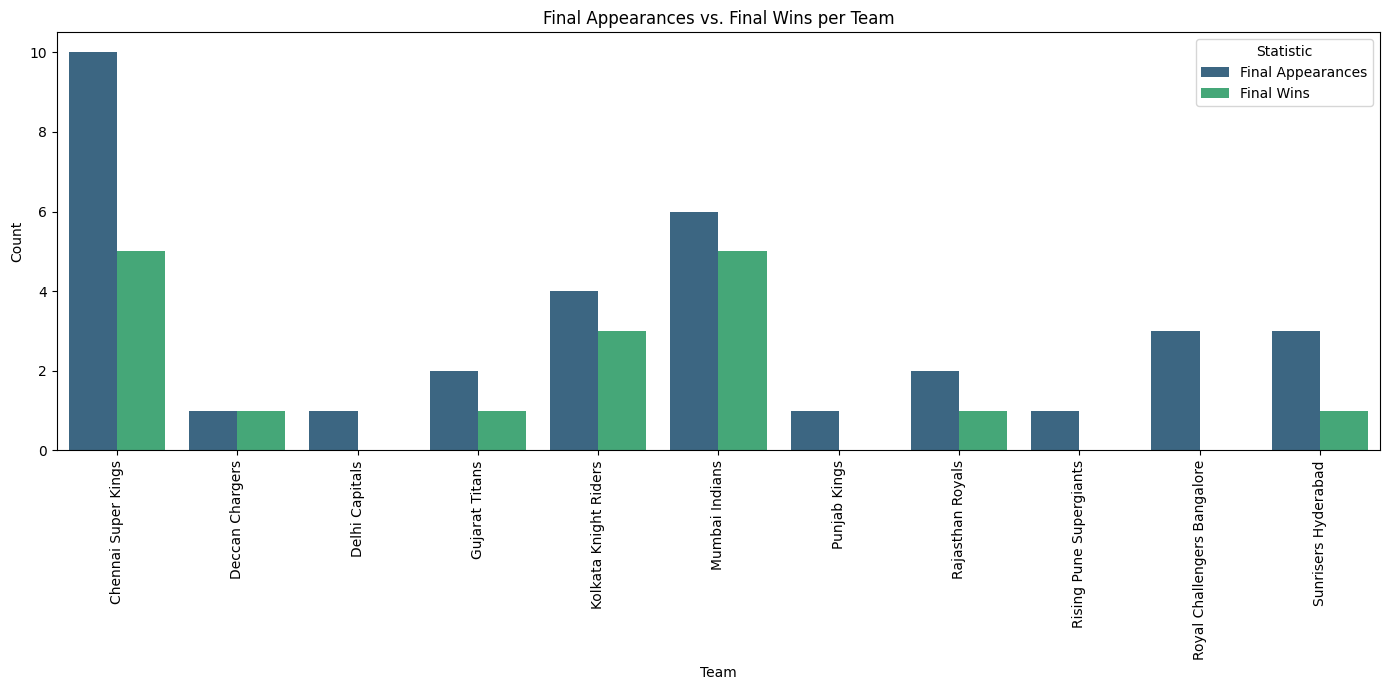

In [ ]:
final_stats_df = pd.DataFrame({'Final Appearances': final_team_counts, 'Final Wins': final_match_winners}).fillna(0)
final_stats_df = final_stats_df.reset_index().rename(columns={'index': 'Team'})
final_stats_melted = final_stats_df.melt(id_vars='Team', var_name='Statistic', value_name='Count')

plt.figure(figsize=(14, 7))
sns.barplot(x='Team', y='Count', hue='Statistic', data=final_stats_melted, palette='viridis')
plt.xlabel("Team")
plt.ylabel("Count")
plt.title("Final Appearances vs. Final Wins per Team")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Number of times each team appeared in playoffs

In [ ]:
playoff_match_types = ['Qualifier', 'Eliminator', 'Final']
playoff_matches = df[df['match_type'].isin(playoff_match_types)]

playoff_team_counts = pd.concat([playoff_matches['team1'], playoff_matches['team2']]).value_counts()

print("Number of times each team appeared in playoffs:")
display(playoff_team_counts)

Number of times each team appeared in playoffs:


,count
Chennai Super Kings,11
Royal Challengers Bangalore,8
Mumbai Indians,8
Kolkata Knight Riders,7
Sunrisers Hyderabad,7
Rajasthan Royals,6
Delhi Capitals,2
Gujarat Titans,2
Lucknow Super Giants,2
Deccan Chargers,1


#**Summary**

Here is a summary of the notebook:


*   Data Loading and Cleaning: The notebook starts by loading the matches.csv dataset and performing data cleaning by dropping unnecessary columns (method, umpire1, umpire2) and standardizing team names.


*   Matches per Season: It analyzes the total number of matches played in each season and calculates the average number of matches per season.


*   Team Performance Analysis: The notebook explores the total matches played by each team, their win-loss records, and calculates their winning percentages.


*   Player of the Match Analysis: It identifies players with the most 'Player of the Match' awards overall and year-by-year, highlighting the top performers.


*   Stadium Analysis: The notebook lists stadiums and their corresponding cities, counts the number of stadiums per city, and analyzes how many matches each team has played at each stadium. It also identifies each team's top
5 most played stadiums and their winning percentages at those stadiums (filtered for stadiums with at least 5 matches played).

*   Playoff and Final Analysis: Finally, the notebook examines the number of times each team has appeared in the IPL finals, won the trophy, and appeared in playoff matches (including Qualifiers, Eliminator, and Finals).